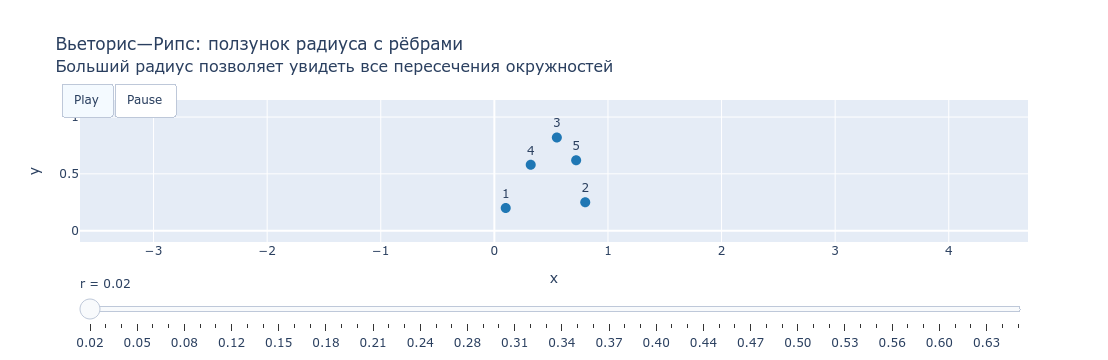

In [5]:
import numpy as np
import plotly.graph_objects as go
from itertools import combinations

pts = np.array([
    [0.10, 0.20],
    [0.80, 0.25],
    [0.55, 0.82],
    [0.32, 0.58],
    [0.72, 0.62],
])


# Было меньше, теперь радиус больше
r_vals = np.linspace(0.02, 0.65, 60)

pairs = list(combinations(range(len(pts)), 2))
pair_dist = {(i, j): np.linalg.norm(pts[i] - pts[j]) for i, j in pairs}

def circle_trace(x, y, r):
    t = np.linspace(0, 2*np.pi, 200)
    return go.Scatter(
        x=x + r*np.cos(t),
        y=y + r*np.sin(t),
        mode='lines',
        line=dict(color='rgba(31,119,180,0.25)', width=2),
        hoverinfo='skip',
        showlegend=False
    )

fig = go.Figure()

# Начальный кадр
r0 = r_vals[0]
for x, y in pts:
    fig.add_trace(circle_trace(x, y, r0))

for i, j in pairs:
    fig.add_trace(go.Scatter(
        x=[pts[i, 0], pts[j, 0]],
        y=[pts[i, 1], pts[j, 1]],
        mode='lines',
        line=dict(color='rgba(214,39,40,0.85)', width=2.5),
        hoverinfo='skip',
        showlegend=False,
        visible=False
    ))

fig.add_trace(go.Scatter(
    x=pts[:, 0],
    y=pts[:, 1],
    mode='markers+text',
    text=[str(i+1) for i in range(len(pts))],
    textposition='top center',
    marker=dict(size=10, color='#1f77b4'),
    name='points'
))

# Кадры
frames = []
for r in r_vals:
    data = [circle_trace(x, y, r) for x, y in pts]

    for i, j in pairs:
        show_edge = pair_dist[(i, j)] <= 2 * r
        data.append(go.Scatter(
            x=[pts[i, 0], pts[j, 0]],
            y=[pts[i, 1], pts[j, 1]],
            mode='lines',
            line=dict(color='rgba(214,39,40,0.85)', width=2.5),
            hoverinfo='skip',
            showlegend=False,
            visible=show_edge
        ))

    data.append(go.Scatter(
        x=pts[:, 0],
        y=pts[:, 1],
        mode='markers+text',
        text=[str(i+1) for i in range(len(pts))],
        textposition='top center',
        marker=dict(size=10, color='#1f77b4'),
        name='points'
    ))

    frames.append(go.Frame(data=data, name=f'{r:.3f}'))

fig.frames = frames

steps = [
    dict(
        method='animate',
        args=[[f'{r:.3f}'], dict(
            mode='immediate',
            frame=dict(duration=0, redraw=True),
            transition=dict(duration=0)
        )],
        label=f'{r:.2f}'
    )
    for r in r_vals
]

fig.update_layout(
    title=dict(
        text='Вьеторис—Рипс: ползунок радиуса с рёбрами<br><span style="font-size: 16px; font-weight: normal;">Больший радиус позволяет увидеть все пересечения окружностей</span>'
    ),
    xaxis=dict(title='x', range=[-0.1, 1.15], scaleanchor='y', scaleratio=1),
    yaxis=dict(title='y', range=[-0.1, 1.15]),
    sliders=[dict(
        active=0,
        currentvalue={'prefix': 'r = '},
        pad={'t': 30},
        steps=steps
    )],
    updatemenus=[dict(
        type='buttons',
        direction='left',
        x=0.1,
        y=1.12,
        buttons=[
            dict(
                label='Play',
                method='animate',
                args=[None, dict(frame=dict(duration=80, redraw=True),
                                 transition=dict(duration=0),
                                 fromcurrent=True)]
            ),
            dict(
                label='Pause',
                method='animate',
                args=[[None], dict(frame=dict(duration=0, redraw=False),
                                   transition=dict(duration=0))]
            )
        ]
    )],
    showlegend=False
)

fig.show()